Traffic Threshold: 992.73

Historical DDoS Attacks:
              timestamp      traffic
40  2026-01-02 16:00:00  1621.923329
41  2026-01-02 17:00:00  1681.568414
42  2026-01-02 18:00:00  1466.217586
43  2026-01-02 19:00:00  1287.944815
90  2026-01-04 18:00:00  1620.853877
91  2026-01-04 19:00:00  1640.432250
92  2026-01-04 20:00:00  1462.897345
150 2026-01-07 06:00:00  1457.524643
151 2026-01-07 07:00:00  1392.322410
152 2026-01-07 08:00:00  1203.998764

ARIMA Forecast:
              timestamp  predicted_traffic  potential_ddos
200 2026-01-09 08:00:00         475.095665           False
201 2026-01-09 09:00:00         511.519923           False
202 2026-01-09 10:00:00         538.910482           False
203 2026-01-09 11:00:00         553.868685           False
204 2026-01-09 12:00:00         558.564739           False
205 2026-01-09 13:00:00         557.094189           False
206 2026-01-09 14:00:00         553.210787           False
207 2026-01-09 15:00:00         549.379523          

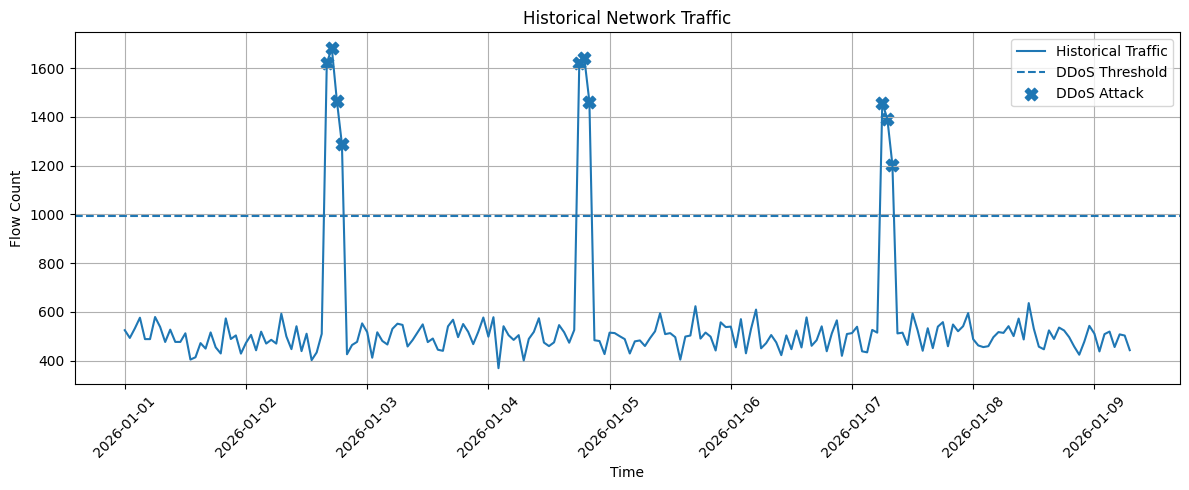

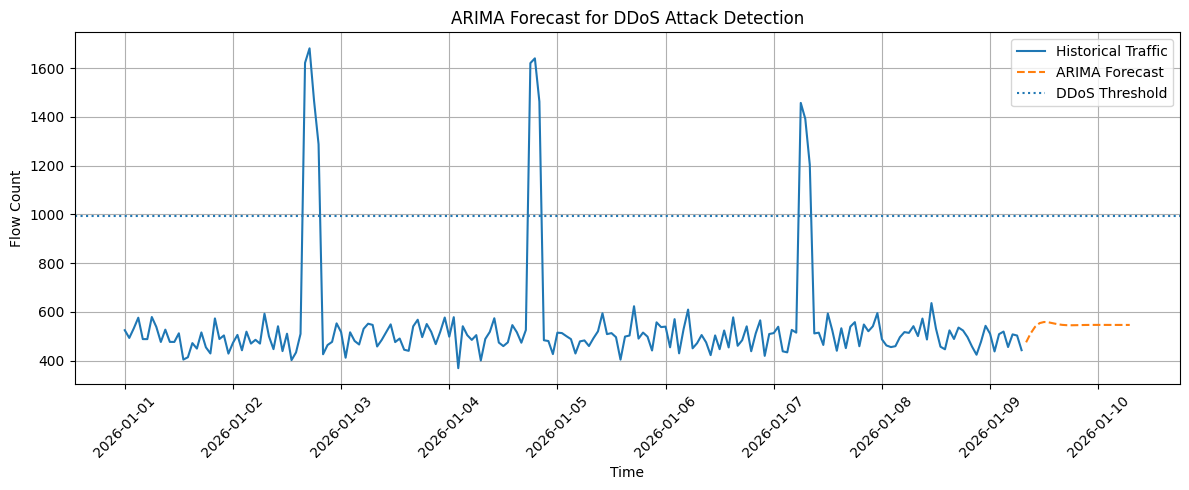

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ---------------------------------------------------------
# 1. CREATE SAMPLE NETWORK TRAFFIC DATA
# ---------------------------------------------------------

np.random.seed(42)

time = pd.date_range(
    start="2026-01-01",
    periods=200,
    freq="h"
)

# Normal network traffic
traffic = 500 + np.random.normal(0, 50, 200)

# Add DDoS traffic spikes
attack_points = [40, 41, 42, 43, 90, 91, 92, 150, 151, 152]

for point in attack_points:
    traffic[point] += np.random.randint(700, 1200)

# Create DataFrame
df = pd.DataFrame({
    "timestamp": time,
    "traffic": traffic
})

df["traffic"] = df["traffic"].clip(lower=50)

# ---------------------------------------------------------
# 2. CALCULATE DDoS THRESHOLD
# ---------------------------------------------------------

mean_traffic = df["traffic"].mean()
std_traffic = df["traffic"].std()

threshold = mean_traffic + (2 * std_traffic)

# Identify historical DDoS attacks
df["actual_attack"] = df["traffic"] > threshold

# ---------------------------------------------------------
# 3. BUILD ARIMA MODEL
# ---------------------------------------------------------

model = ARIMA(
    df["traffic"],
    order=(2, 1, 2)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 4. FORECAST NEXT 24 HOURS
# ---------------------------------------------------------

future_points = 24

forecast = model_fit.forecast(
    steps=future_points
)

future_time = pd.date_range(
    start=df["timestamp"].iloc[-1] + pd.Timedelta(hours=1),
    periods=future_points,
    freq="h"
)

forecast_df = pd.DataFrame({
    "timestamp": future_time,
    "predicted_traffic": forecast
})

# Check potential DDoS attacks
forecast_df["potential_ddos"] = (
    forecast_df["predicted_traffic"] > threshold
)

# ---------------------------------------------------------
# 5. DISPLAY RESULTS
# ---------------------------------------------------------

print("Traffic Threshold:", round(threshold, 2))

print("\nHistorical DDoS Attacks:")
print(
    df[df["actual_attack"]][
        ["timestamp", "traffic"]
    ]
)

print("\nARIMA Forecast:")
print(forecast_df)

# ---------------------------------------------------------
# 6. GRAPH 1 - HISTORICAL NETWORK TRAFFIC
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    df["timestamp"],
    df["traffic"],
    label="Historical Traffic"
)

# Threshold line
plt.axhline(
    y=threshold,
    linestyle="--",
    label="DDoS Threshold"
)

# Mark historical attacks
attack_data = df[df["actual_attack"]]

plt.scatter(
    attack_data["timestamp"],
    attack_data["traffic"],
    marker="X",
    s=80,
    label="DDoS Attack"
)

plt.title("Historical Network Traffic")
plt.xlabel("Time")
plt.ylabel("Flow Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. GRAPH 2 - ARIMA FORECAST
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))

# Historical traffic
plt.plot(
    df["timestamp"],
    df["traffic"],
    label="Historical Traffic"
)

# Forecast
plt.plot(
    forecast_df["timestamp"],
    forecast_df["predicted_traffic"],
    linestyle="--",
    label="ARIMA Forecast"
)

# DDoS threshold
plt.axhline(
    y=threshold,
    linestyle=":",
    label="DDoS Threshold"
)

# Predicted DDoS attacks
predicted_attacks = forecast_df[
    forecast_df["potential_ddos"]
]

if len(predicted_attacks) > 0:

    plt.scatter(
        predicted_attacks["timestamp"],
        predicted_attacks["predicted_traffic"],
        marker="X",
        s=100,
        label="Predicted DDoS"
    )

plt.title("ARIMA Forecast for DDoS Attack Detection")
plt.xlabel("Time")
plt.ylabel("Flow Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()